In [224]:
import importlib
import json
import matplotlib.pyplot as plt
import numpy as np

from lust_codesnippets_py.styles import matplotlib_style as alstms

plt.rcdefaults()


## Custom Colormaps Have Been Registered

['fink_r', 'fink', 'Grays_r', 'gist_yerg_r', 'gist_grey_r', 'grey_r', 'tab20c_r', 'tab20b_r', 'tab20_r', 'tab10_r', 'Set3_r', 'Set2_r', 'Set1_r', 'Pastel2_r', 'Pastel1_r', 'Paired_r', 'Dark2_r', 'Accent_r', 'winter_r', 'terrain_r', 'summer_r', 'spring_r', 'seismic_r', 'rainbow_r', 'prism_r', 'pink_r', 'ocean_r', 'nipy_spectral_r', 'jet_r', 'hsv_r', 'hot_r', 'gray_r', 'gnuplot2_r', 'gnuplot_r', 'gist_yarg_r', 'gist_stern_r', 'gist_rainbow_r', 'gist_ncar_r', 'gist_heat_r', 'gist_gray_r', 'gist_earth_r', 'flag_r', 'cubehelix_r', 'copper_r', 'coolwarm_r', 'cool_r', 'bwr_r', 'brg_r', 'bone_r', 'binary_r', 'autumn_r', 'afmhot_r', 'YlOrRd_r', 'YlOrBr_r', 'YlGnBu_r', 'YlGn_r', 'Wistia_r', 'Spectral_r', 'Reds_r', 'RdYlGn_r', 'RdYlBu_r', 'RdPu_r', 'RdGy_r', 'RdBu_r', 'Purples_r', 'PuRd_r', 'PuOr_r', 'PuBuGn_r', 'PuBu_r', 'PiYG_r', 'PRGn_r', 'Oranges_r', 'OrRd_r', 'Greys_r', 'Greens_r', 'GnBu_r', 'CMRmap_r', 'BuPu_r', 'BuGn_r', 'BrBG_r', 'Blues_r', 'vanimo_r', 'managua_r', 'berlin_r', 'turbo_r', 

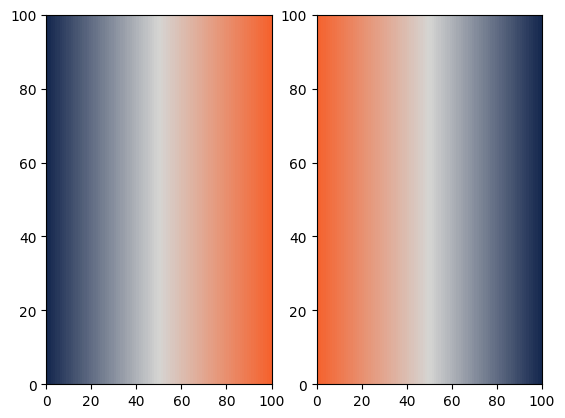

In [225]:
#new colormaps available globally by name
print(list(plt.colormaps)[::-1])

#fink
fig, axs = plt.subplots(1,2)
axs[0].pcolormesh(np.linspace(np.zeros(100), 1, 100).T, cmap="fink")
axs[1].pcolormesh(np.linspace(np.zeros(100), 1, 100).T, cmap="fink_r")


# Define a Plot for Testing

In [226]:
def style_testplot(colorway=None, ls=None, markers=None, cmap=None, hatches=None):
    """
        - function defining a testplot to compare different styles with each other
    """
    
    
    #load predefined plot from json
    with open("../../styles/demos/style_demo.json", "r") as f:
        data = json.load(f)
    traces = data["traces"]

    scatters_lines  = list(filter(lambda trace: trace["type"]=="scatter", traces))
    heatmaps        = list(filter(lambda trace: trace["type"]=="heatmap", traces))
    histograms      = list(filter(lambda trace: trace["type"]=="histogram", traces))
    surfaces        = list(filter(lambda trace: trace["type"]=="surface", traces))
    scatters        = list(filter(lambda trace: trace["mode"]=="markers", scatters_lines))
    lines           = list(filter(lambda trace: trace["mode"]=="lines", scatters_lines))

    #plotting
    fig = plt.figure(figsize=(16,16))
    fig.suptitle("Suptitle")
    ax1 = fig.add_subplot(321, title="ax1", xlabel="x", ylabel="y")
    ax2 = fig.add_subplot(322, title="ax2", xlabel="x", ylabel="y")
    ax3 = fig.add_subplot(323, title="ax3", xlabel="x", ylabel="y")
    ax4 = fig.add_subplot(324, title="ax4", xlabel="x", ylabel="y", zlabel="z", projection="3d")
    ax5 = fig.add_subplot(313, title="ax5", xlabel="x", ylabel="Counts")

    for idx, series in enumerate(lines):
        ax1.plot(series["x"], series["y"], label=series["name"])
    for idx, series in enumerate(scatters):
        if "marker" in series.keys(): c, cmap = series["marker"]["color"], series["marker"]["colorscale"].lower()
        else: c, cmap = None, None
        
        x_error = series["error_x"]["array"] if "error_x" in series.keys() else None
        y_error = series["error_y"]["array"] if "error_y" in series.keys() else None
        if x_error is None and y_error is None:
            sctr = ax2.scatter(series["x"], series["y"], label=series["name"], marker=markers[idx], c=c, cmap=cmap)
        else:
            ebar = ax2.errorbar(series["x"], series["y"], xerr=x_error, yerr=y_error, ls="", marker="o")
    for idx, series in enumerate(heatmaps):
        mesh = ax3.pcolormesh(series["z"])
        cbar = fig.colorbar(mesh, ax=ax3)
        cbar.ax.tick_params(which="both", direction="out")
        cbar.ax.minorticks_off()
        cbar.set_label(series["colorbar"]["title"]["text"])
    for idx, series in enumerate(surfaces):
        surf = ax4.plot_surface(np.array(series["x"]), np.array(series["y"]), np.array(series["z"]), cmap=cmap)
        cbar = fig.colorbar(surf, ax=ax4)
        cbar.ax.tick_params(which="both", direction="out")
        cbar.ax.minorticks_off()
        cbar.set_label(series["colorbar"]["title"]["text"])        
    for idx, series in enumerate(histograms):
        ax5.hist(series["x"], histtype=["step", "stepfilled"][idx])
    
    ax1.legend(title="LEGTITLE")
    ax2.legend(title="LEGTITLE")
    
    fig.tight_layout()
    plt.show()

    return


# Different Defined Styles

### `tre("dark","cycle")`

/home/lukas/github/LuStCodeSnippets/lust_codesnippets_py/styles/matplotlib_style.py:26: UserWarning: Overwriting the cmap 'fink' that was already in the registry.
  mpl.colormaps.register(cmap, force=True)
/home/lukas/github/LuStCodeSnippets/lust_codesnippets_py/styles/matplotlib_style.py:27: UserWarning: Overwriting the cmap 'fink_r' that was already in the registry.
  mpl.colormaps.register(cmap_r, force=True)


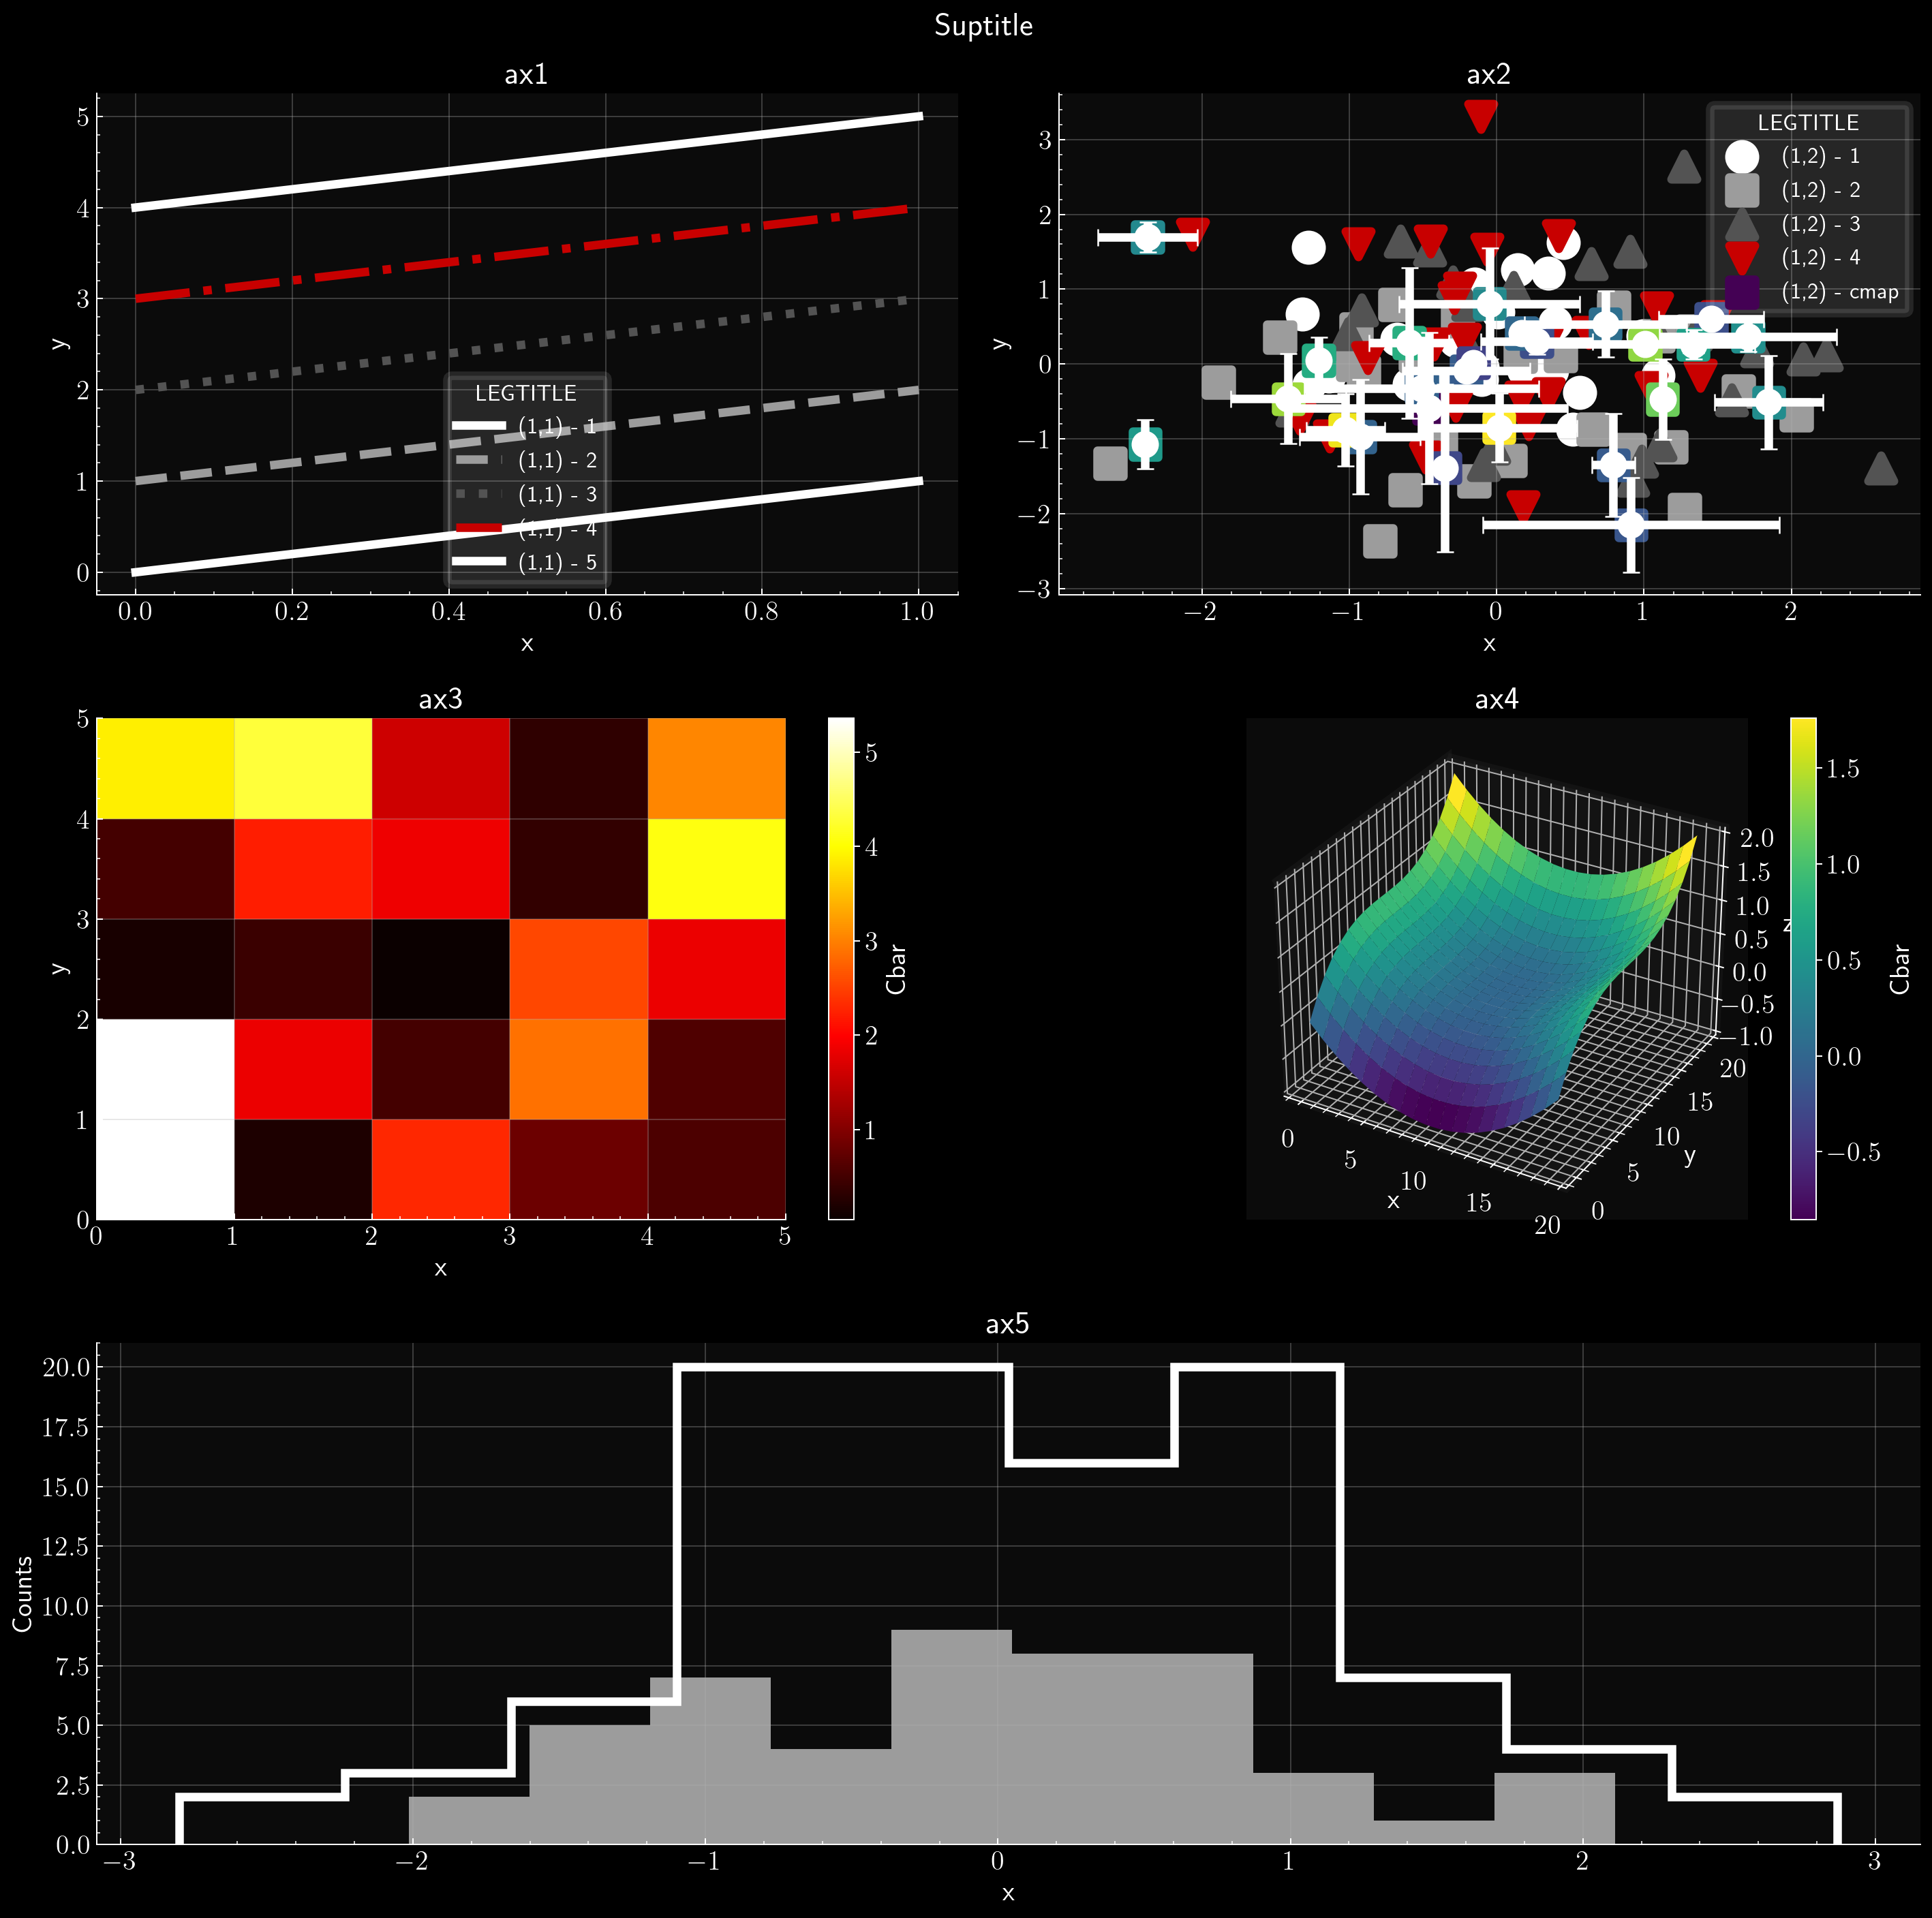

In [227]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.tre("dark","cycle")

style_testplot(colorway, ls, markers, cmap)


### `tre("light","batch")`

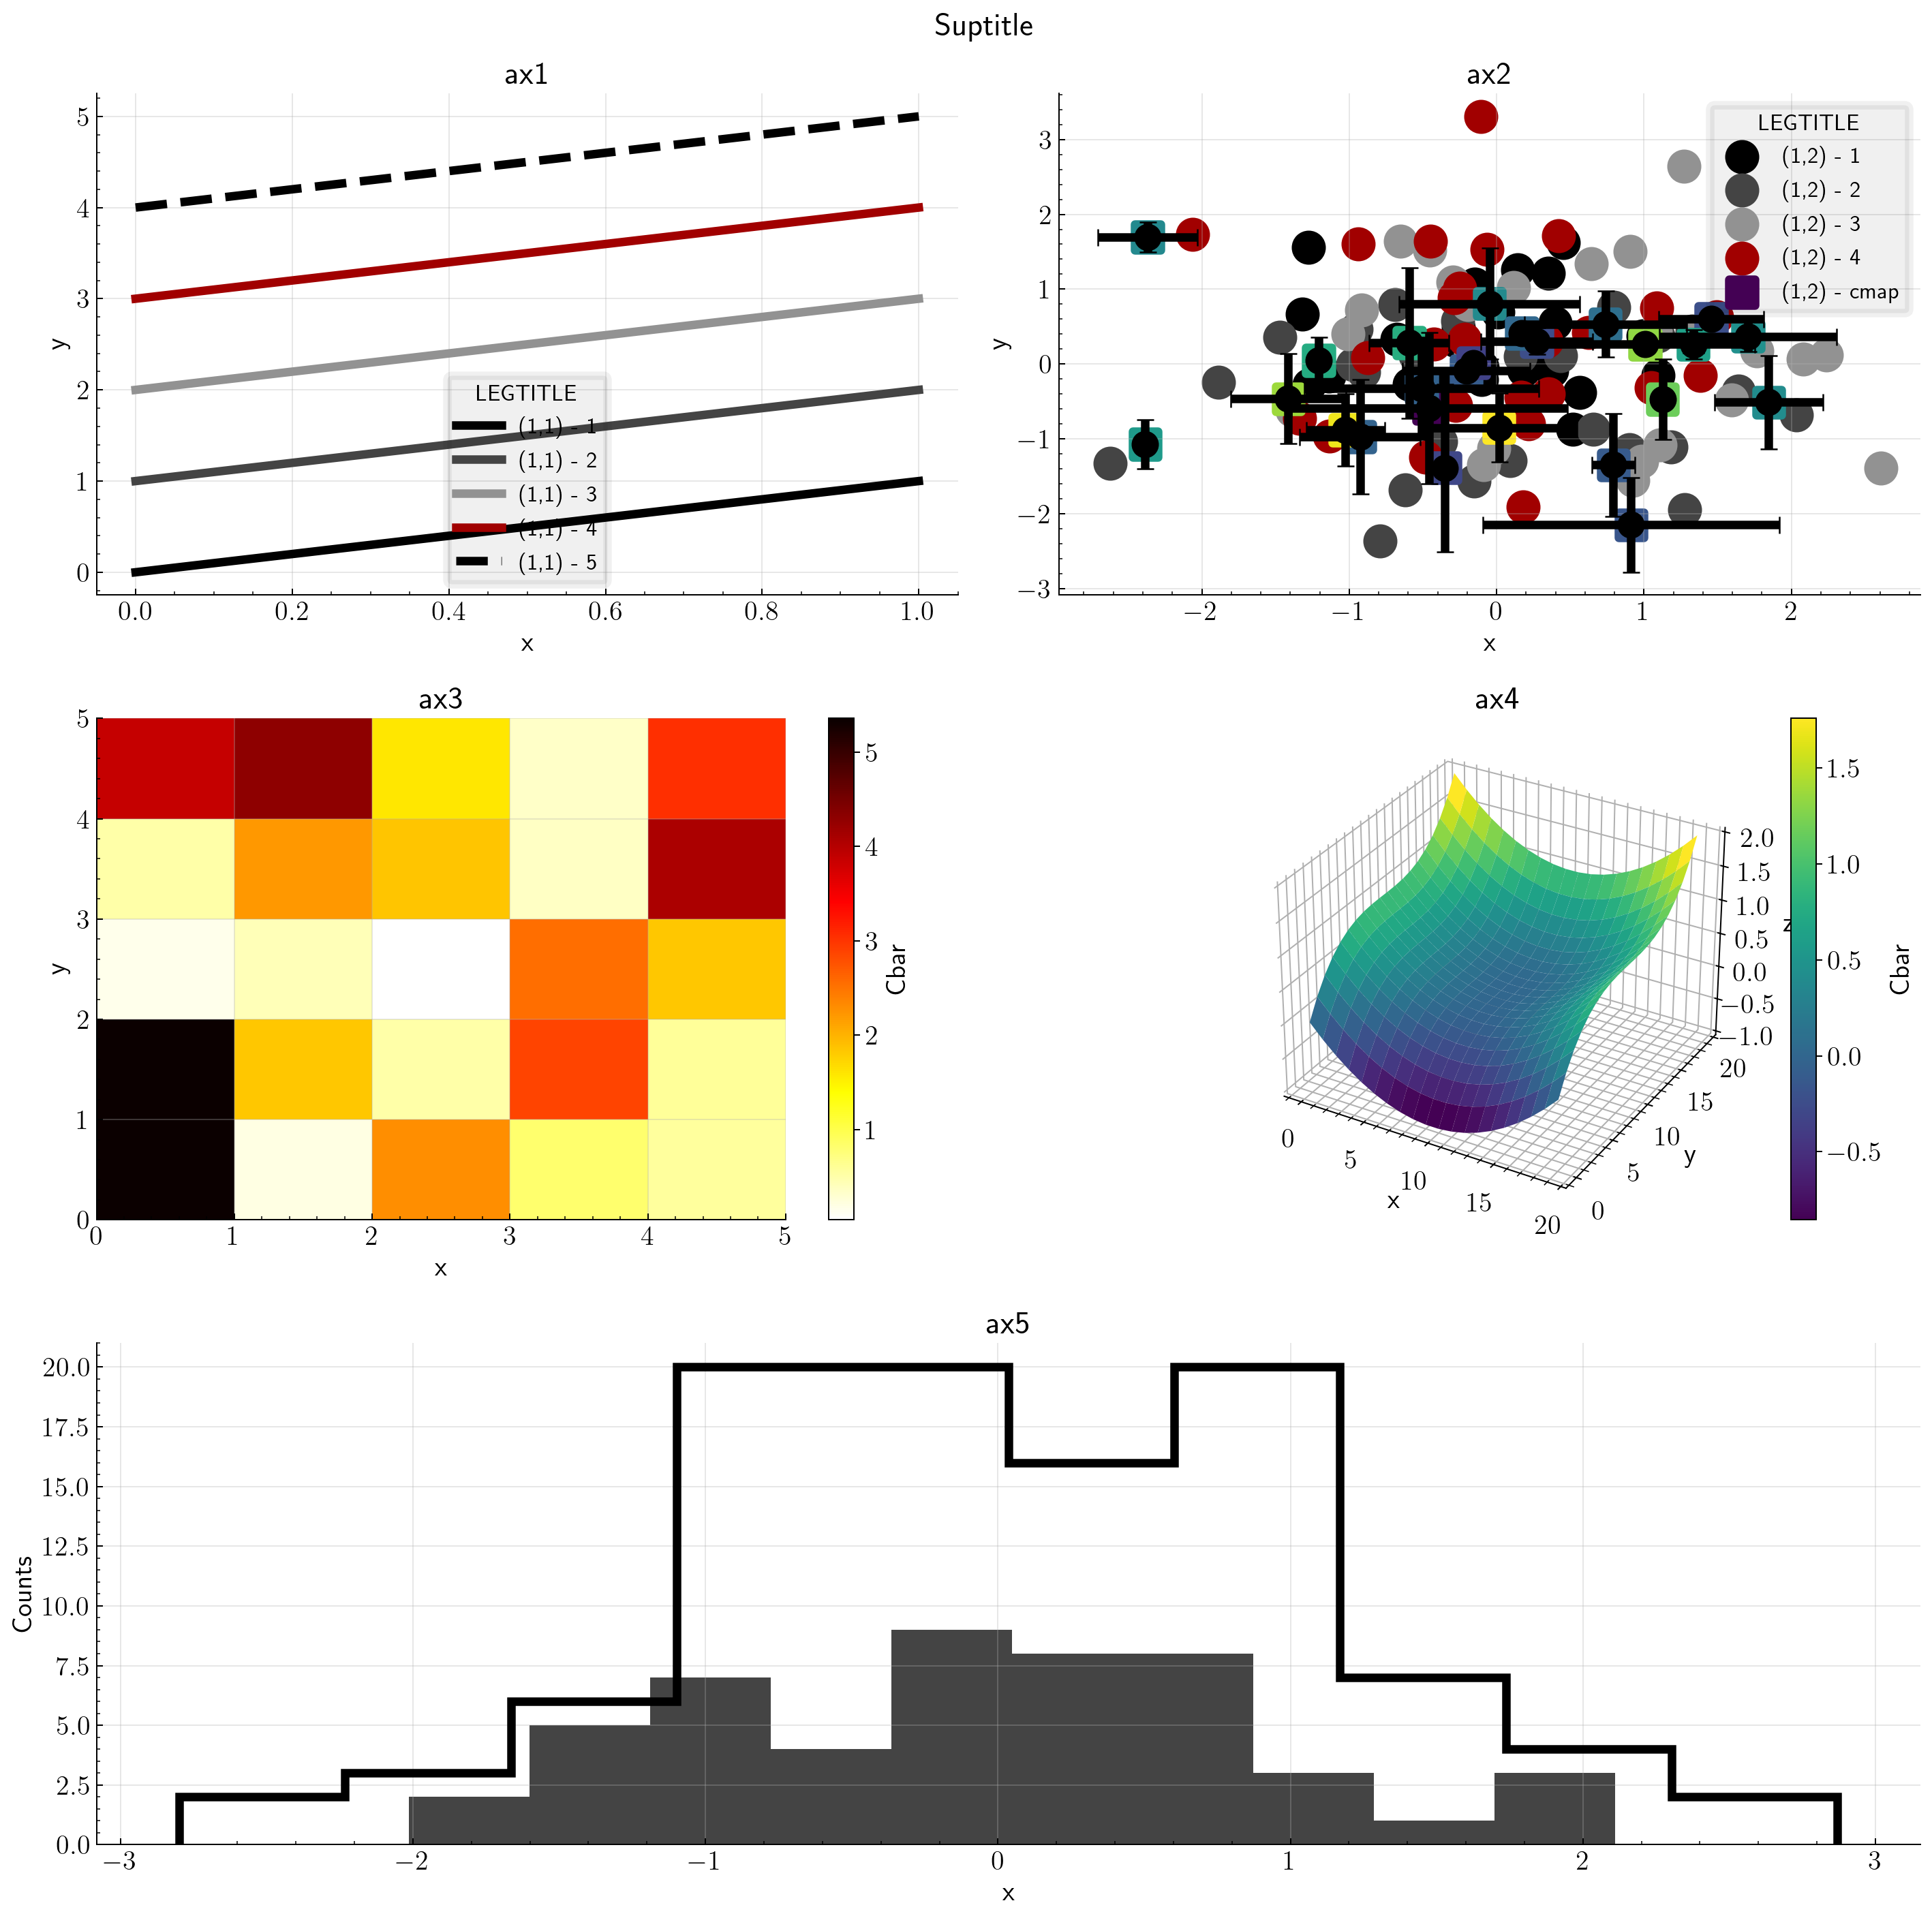

In [228]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.tre("light","batch")

style_testplot(colorway, ls, markers, cmap, hatches)


### `lust("dark","batch")`

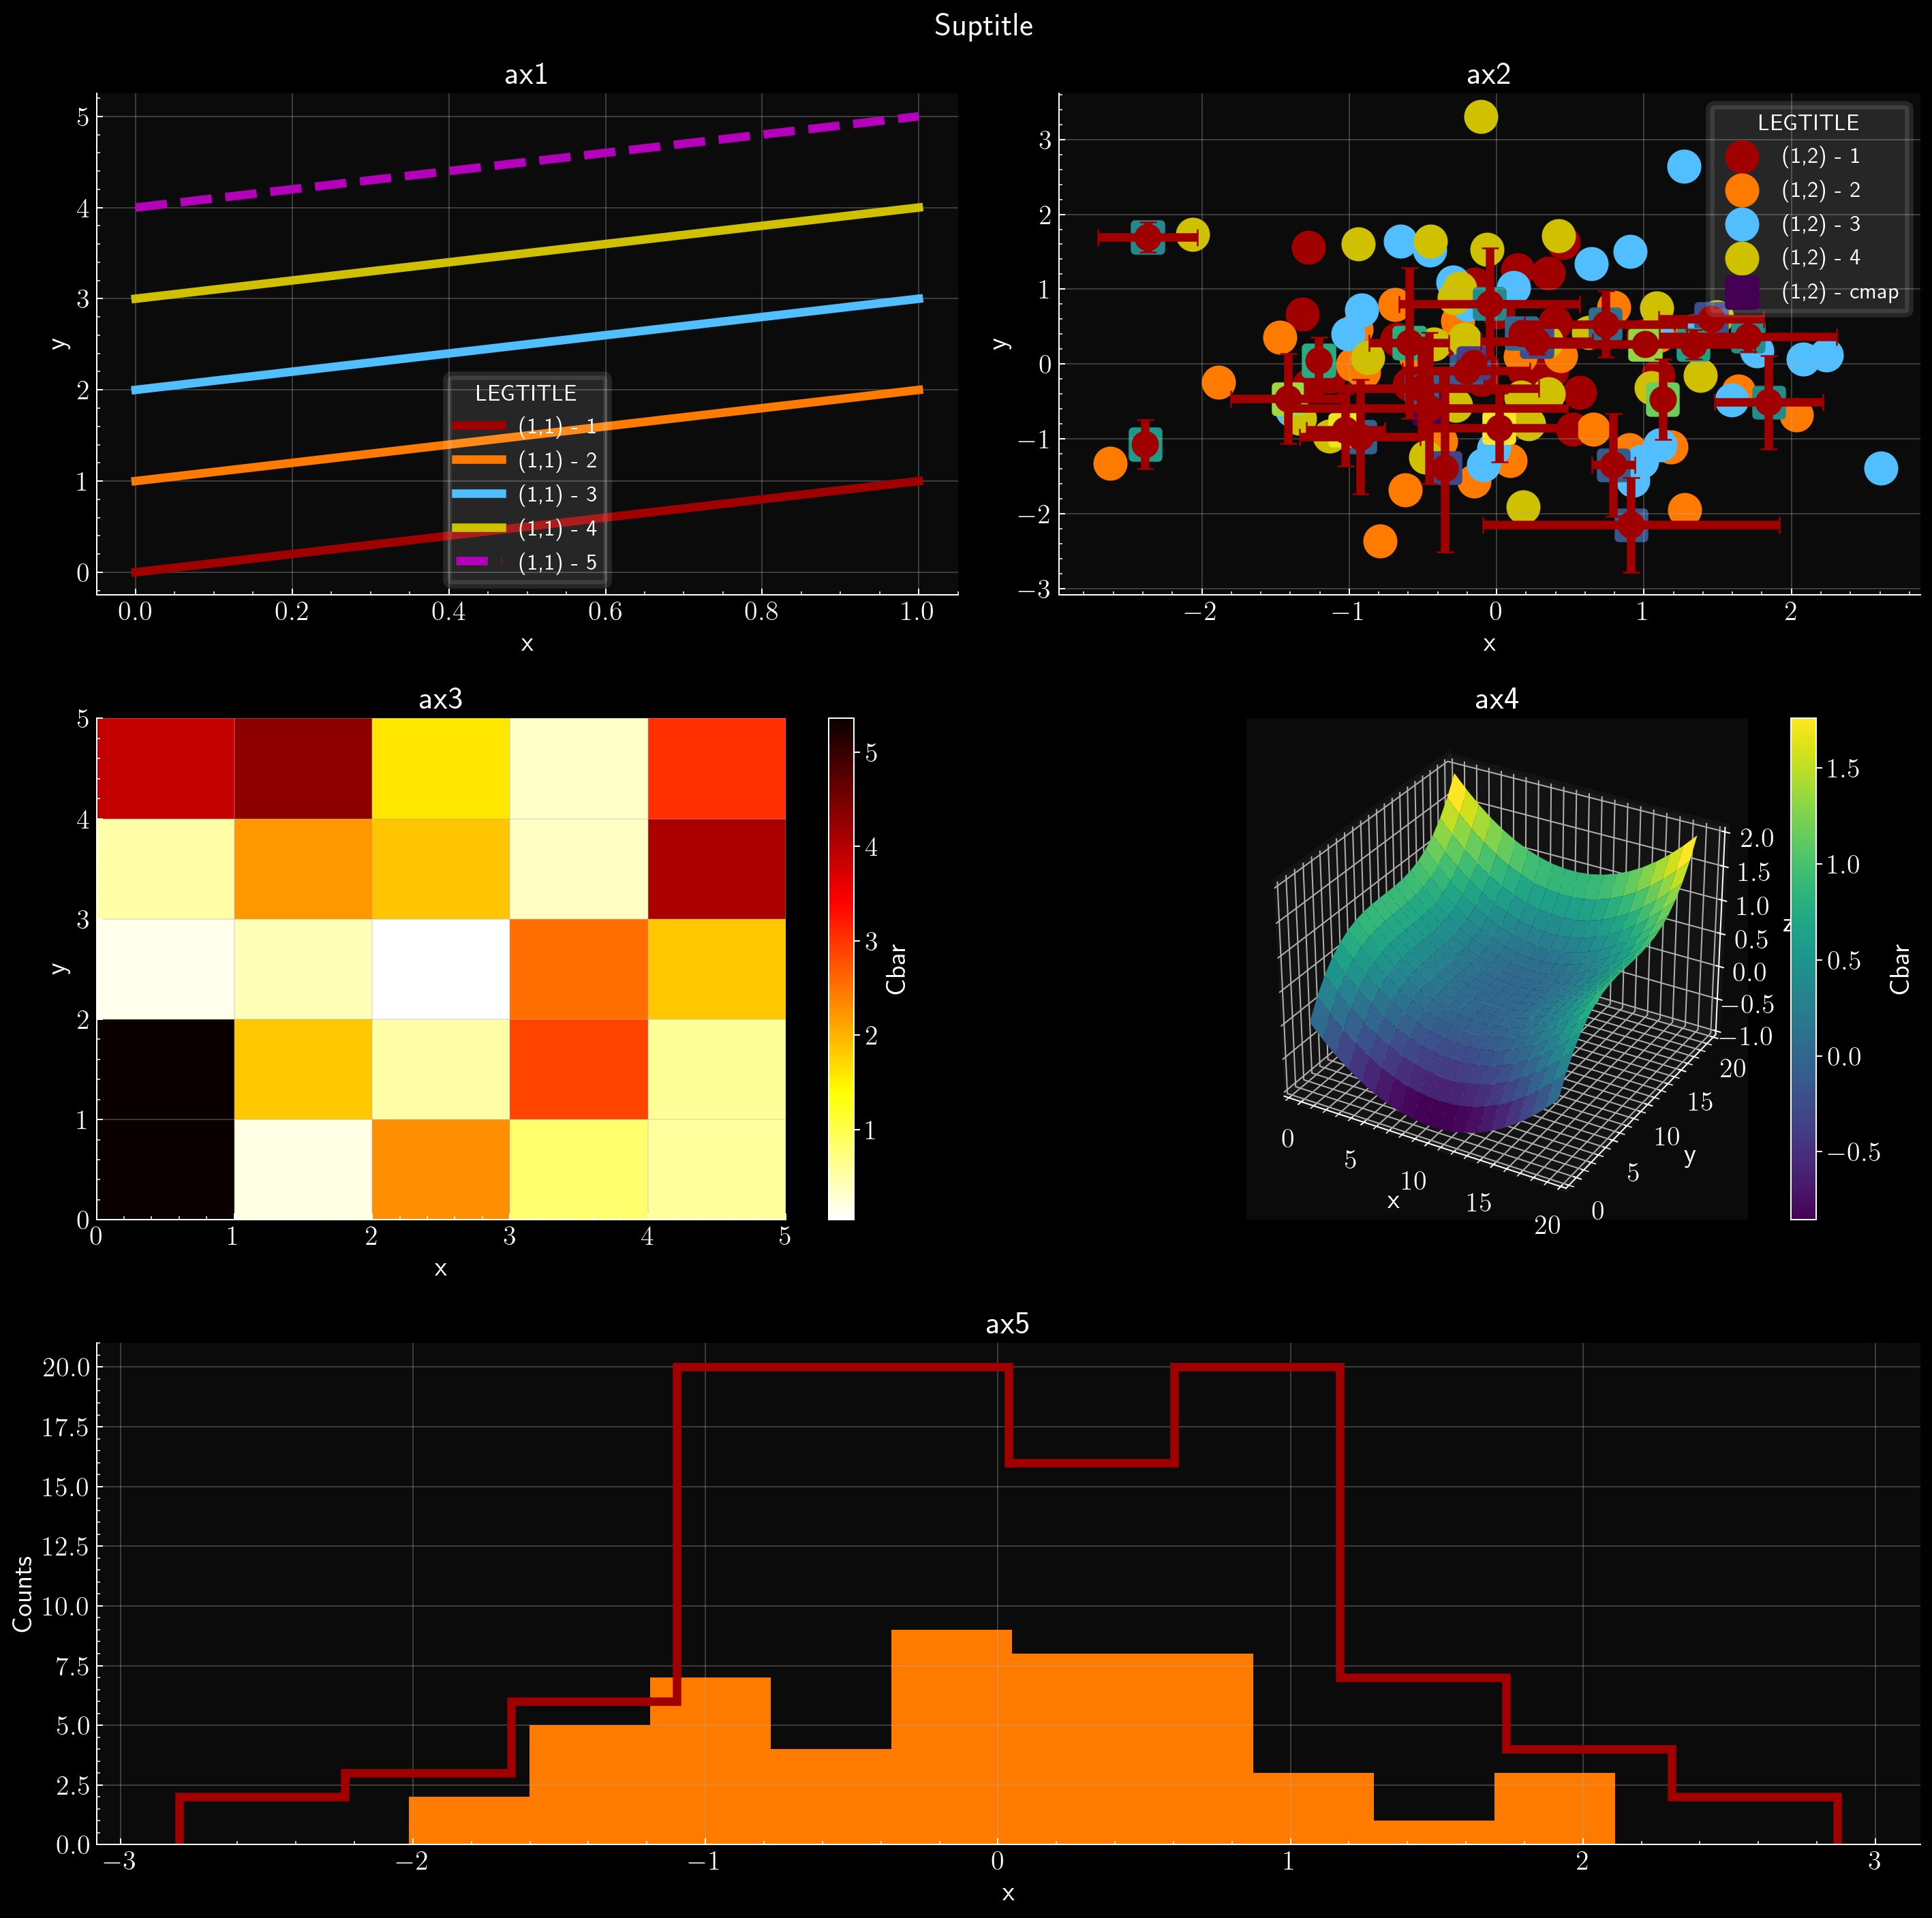

In [229]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.lust("dark", "batch")

style_testplot(colorway, ls, markers, cmap, hatches)


### `lust("light","cycle")`

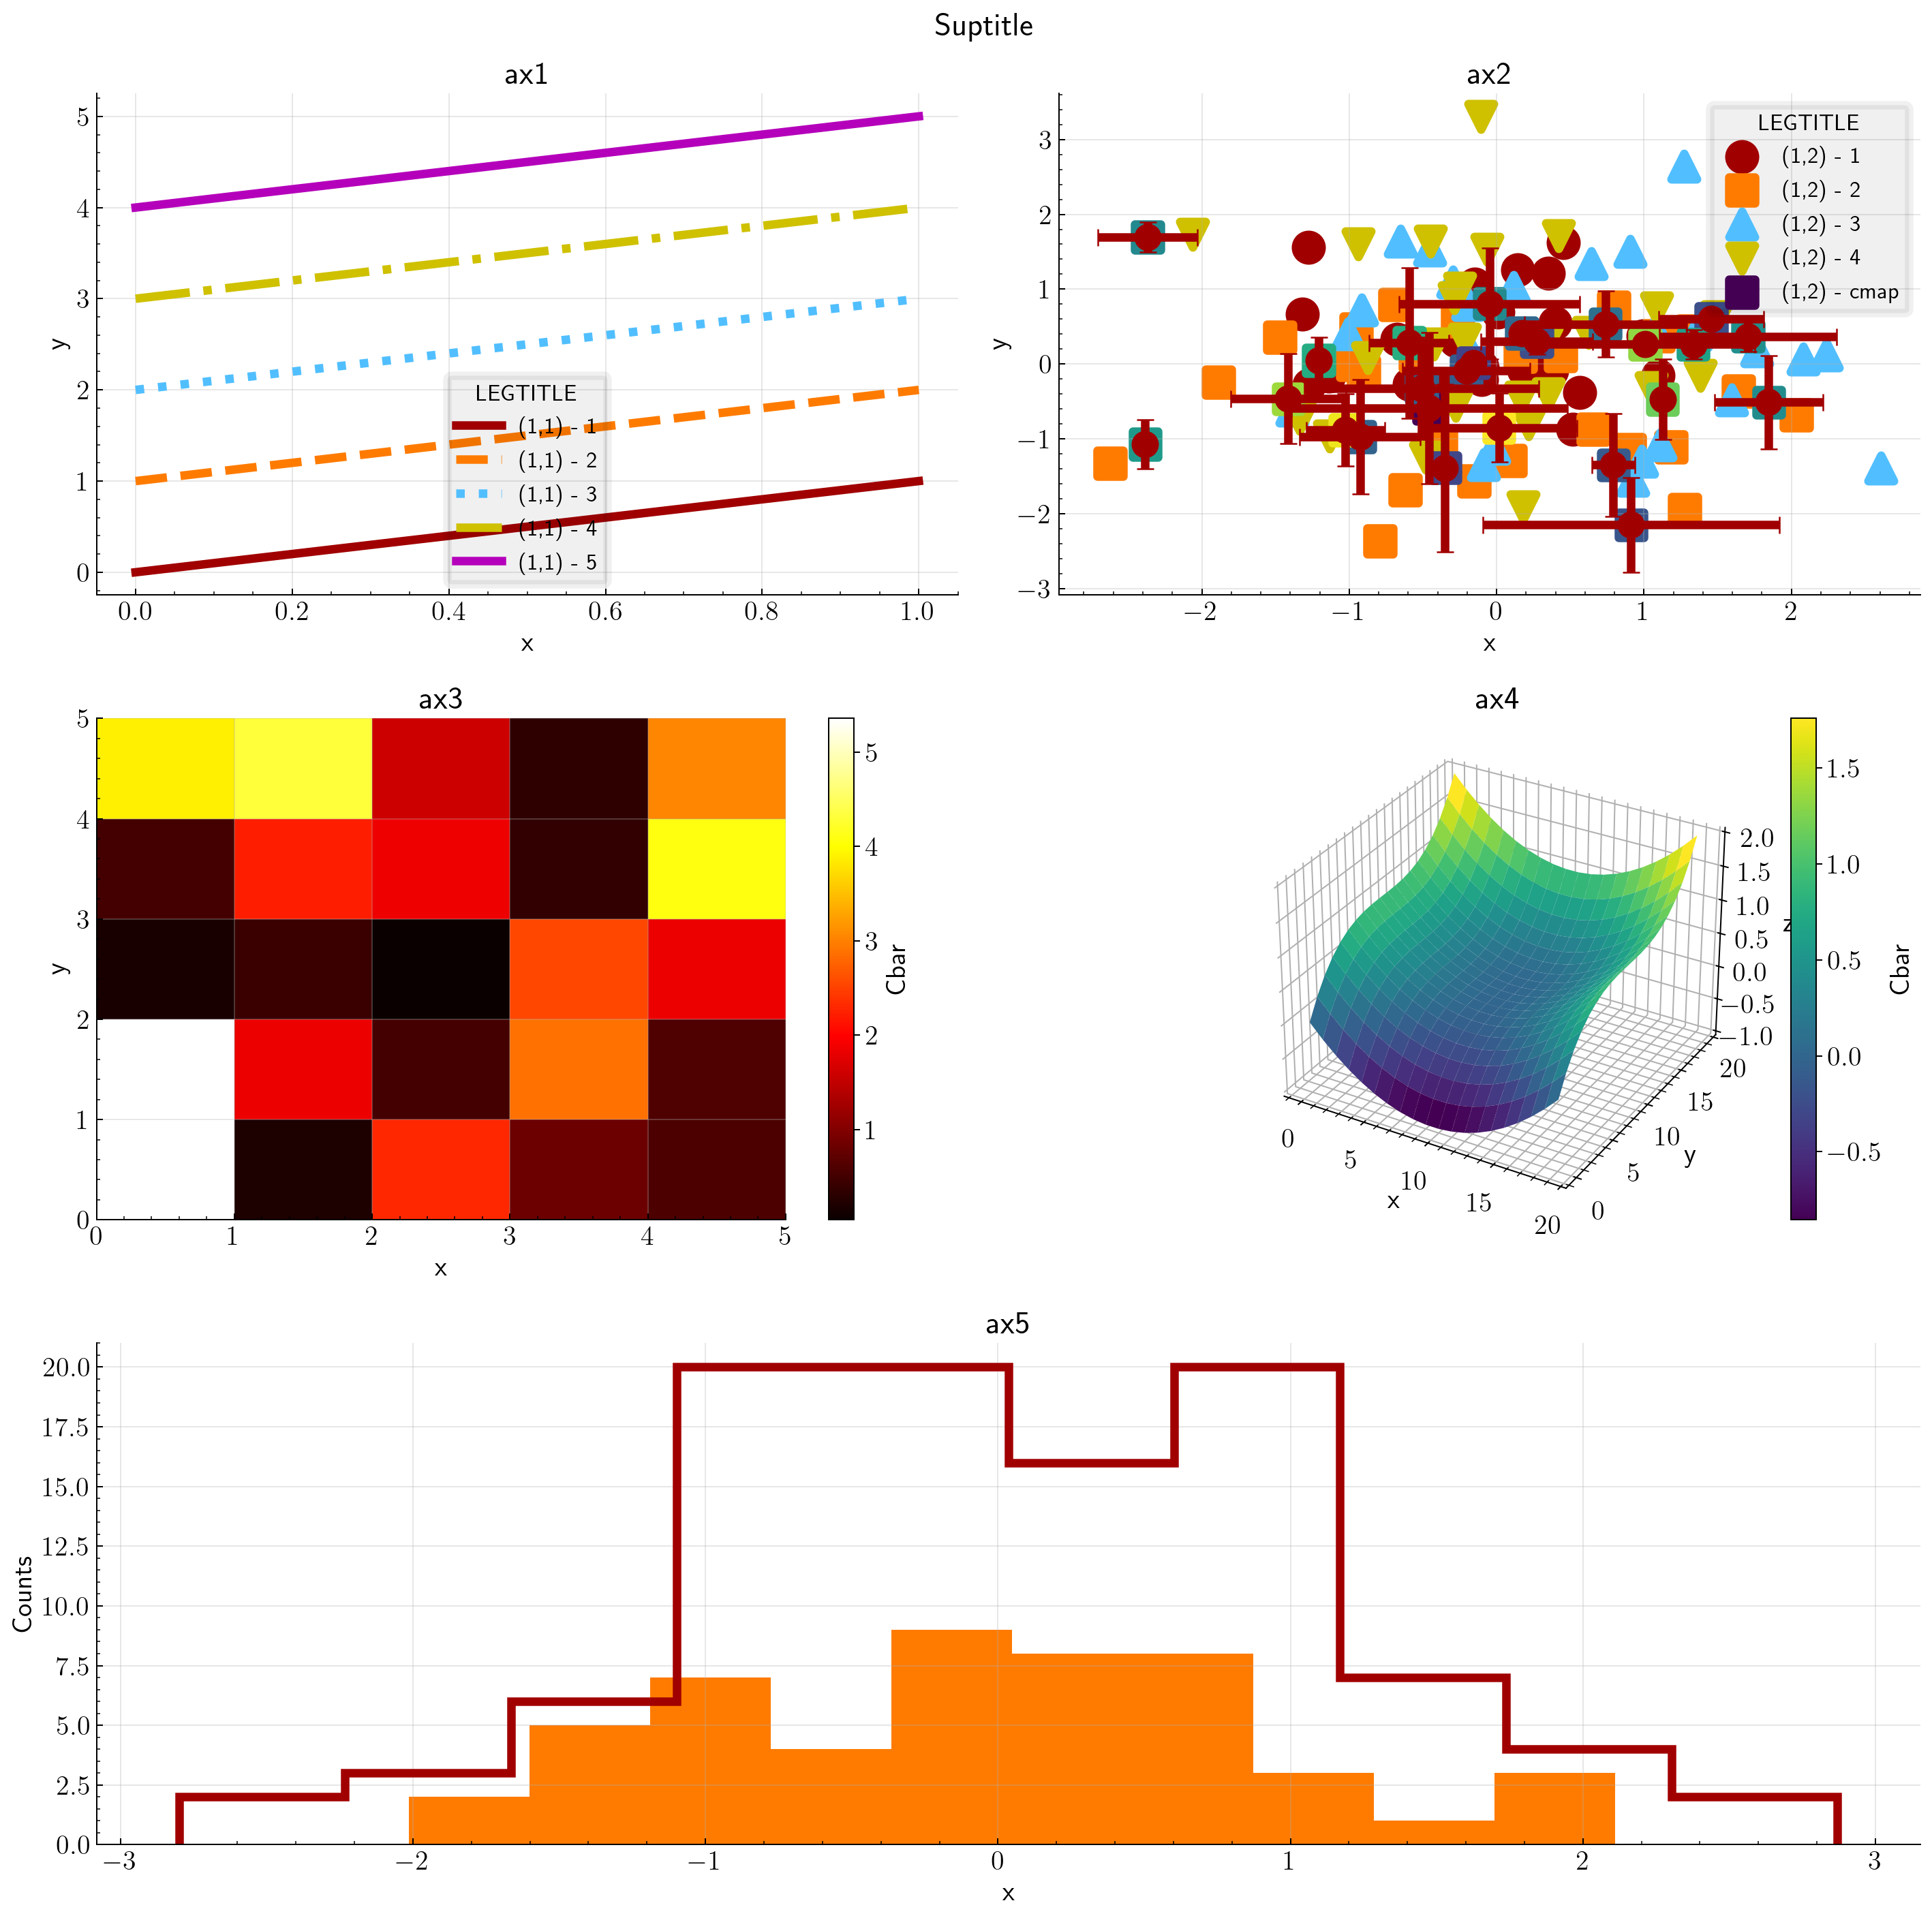

In [230]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.lust("light","cycle")

style_testplot(colorway, ls, markers, cmap, hatches)


### [FINK](https://fink-broker.org/)

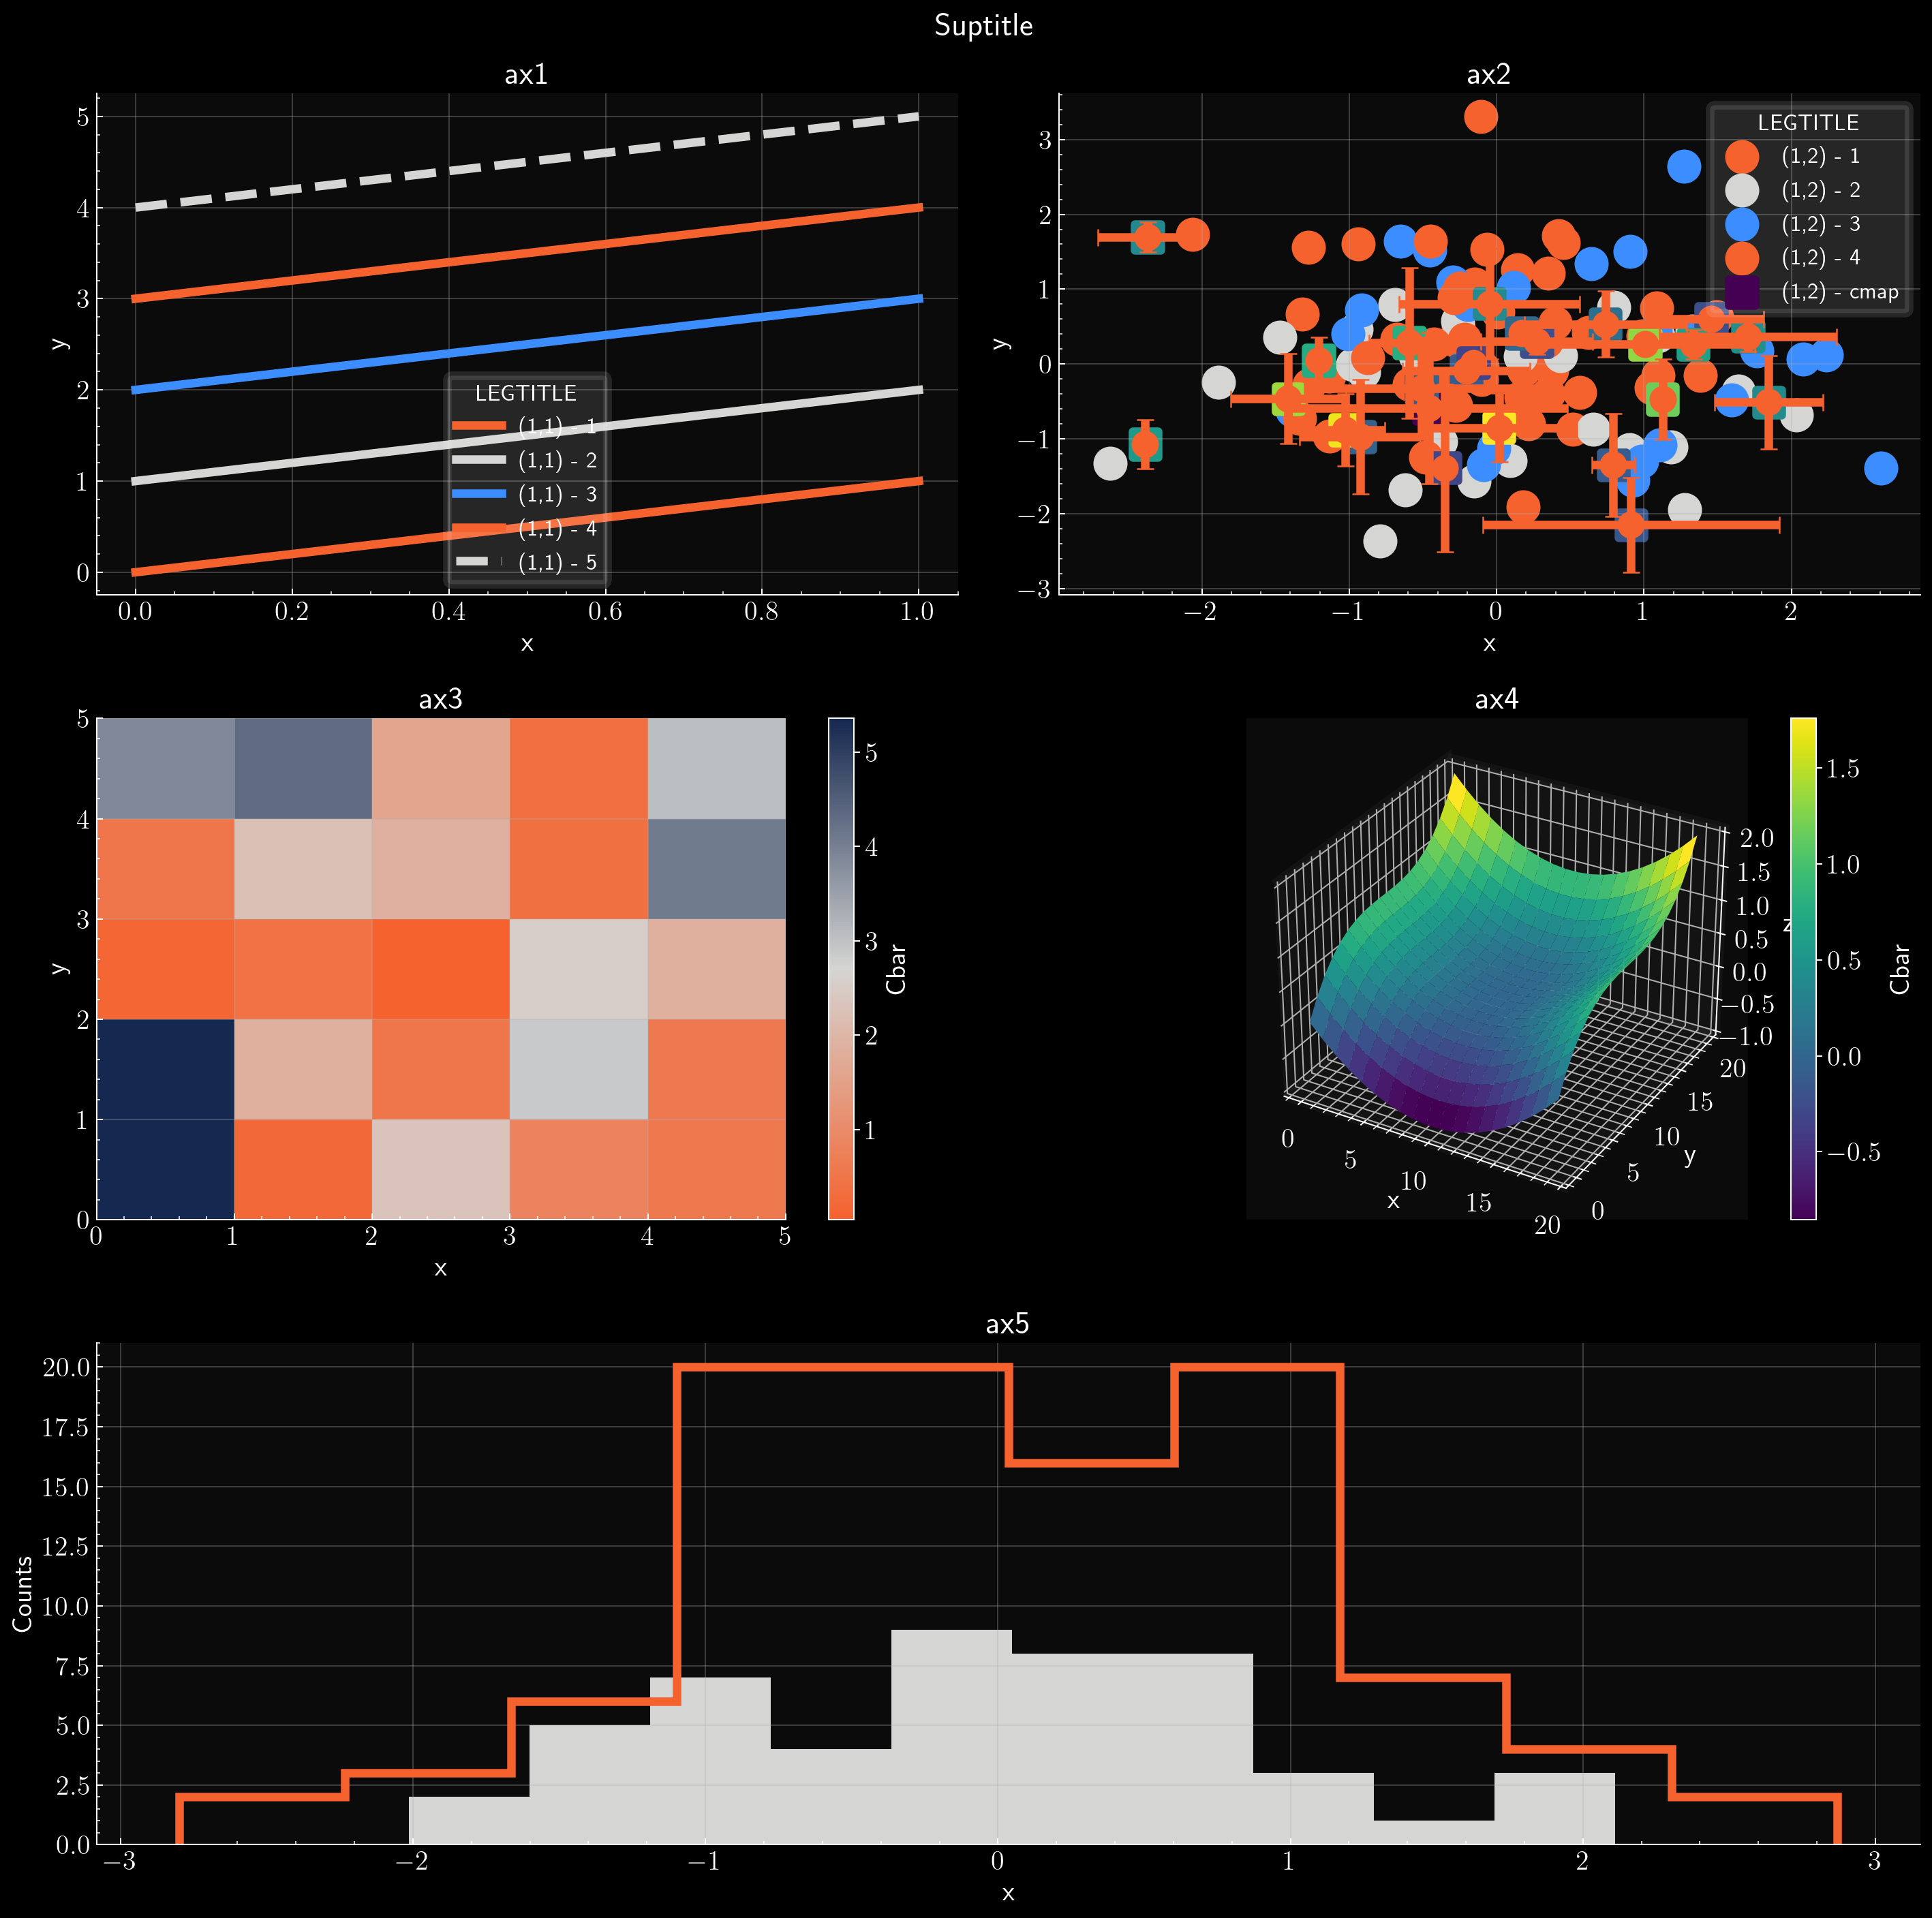

In [231]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.fink("dark","batch")

style_testplot(colorway, ls, markers, cmap, hatches)


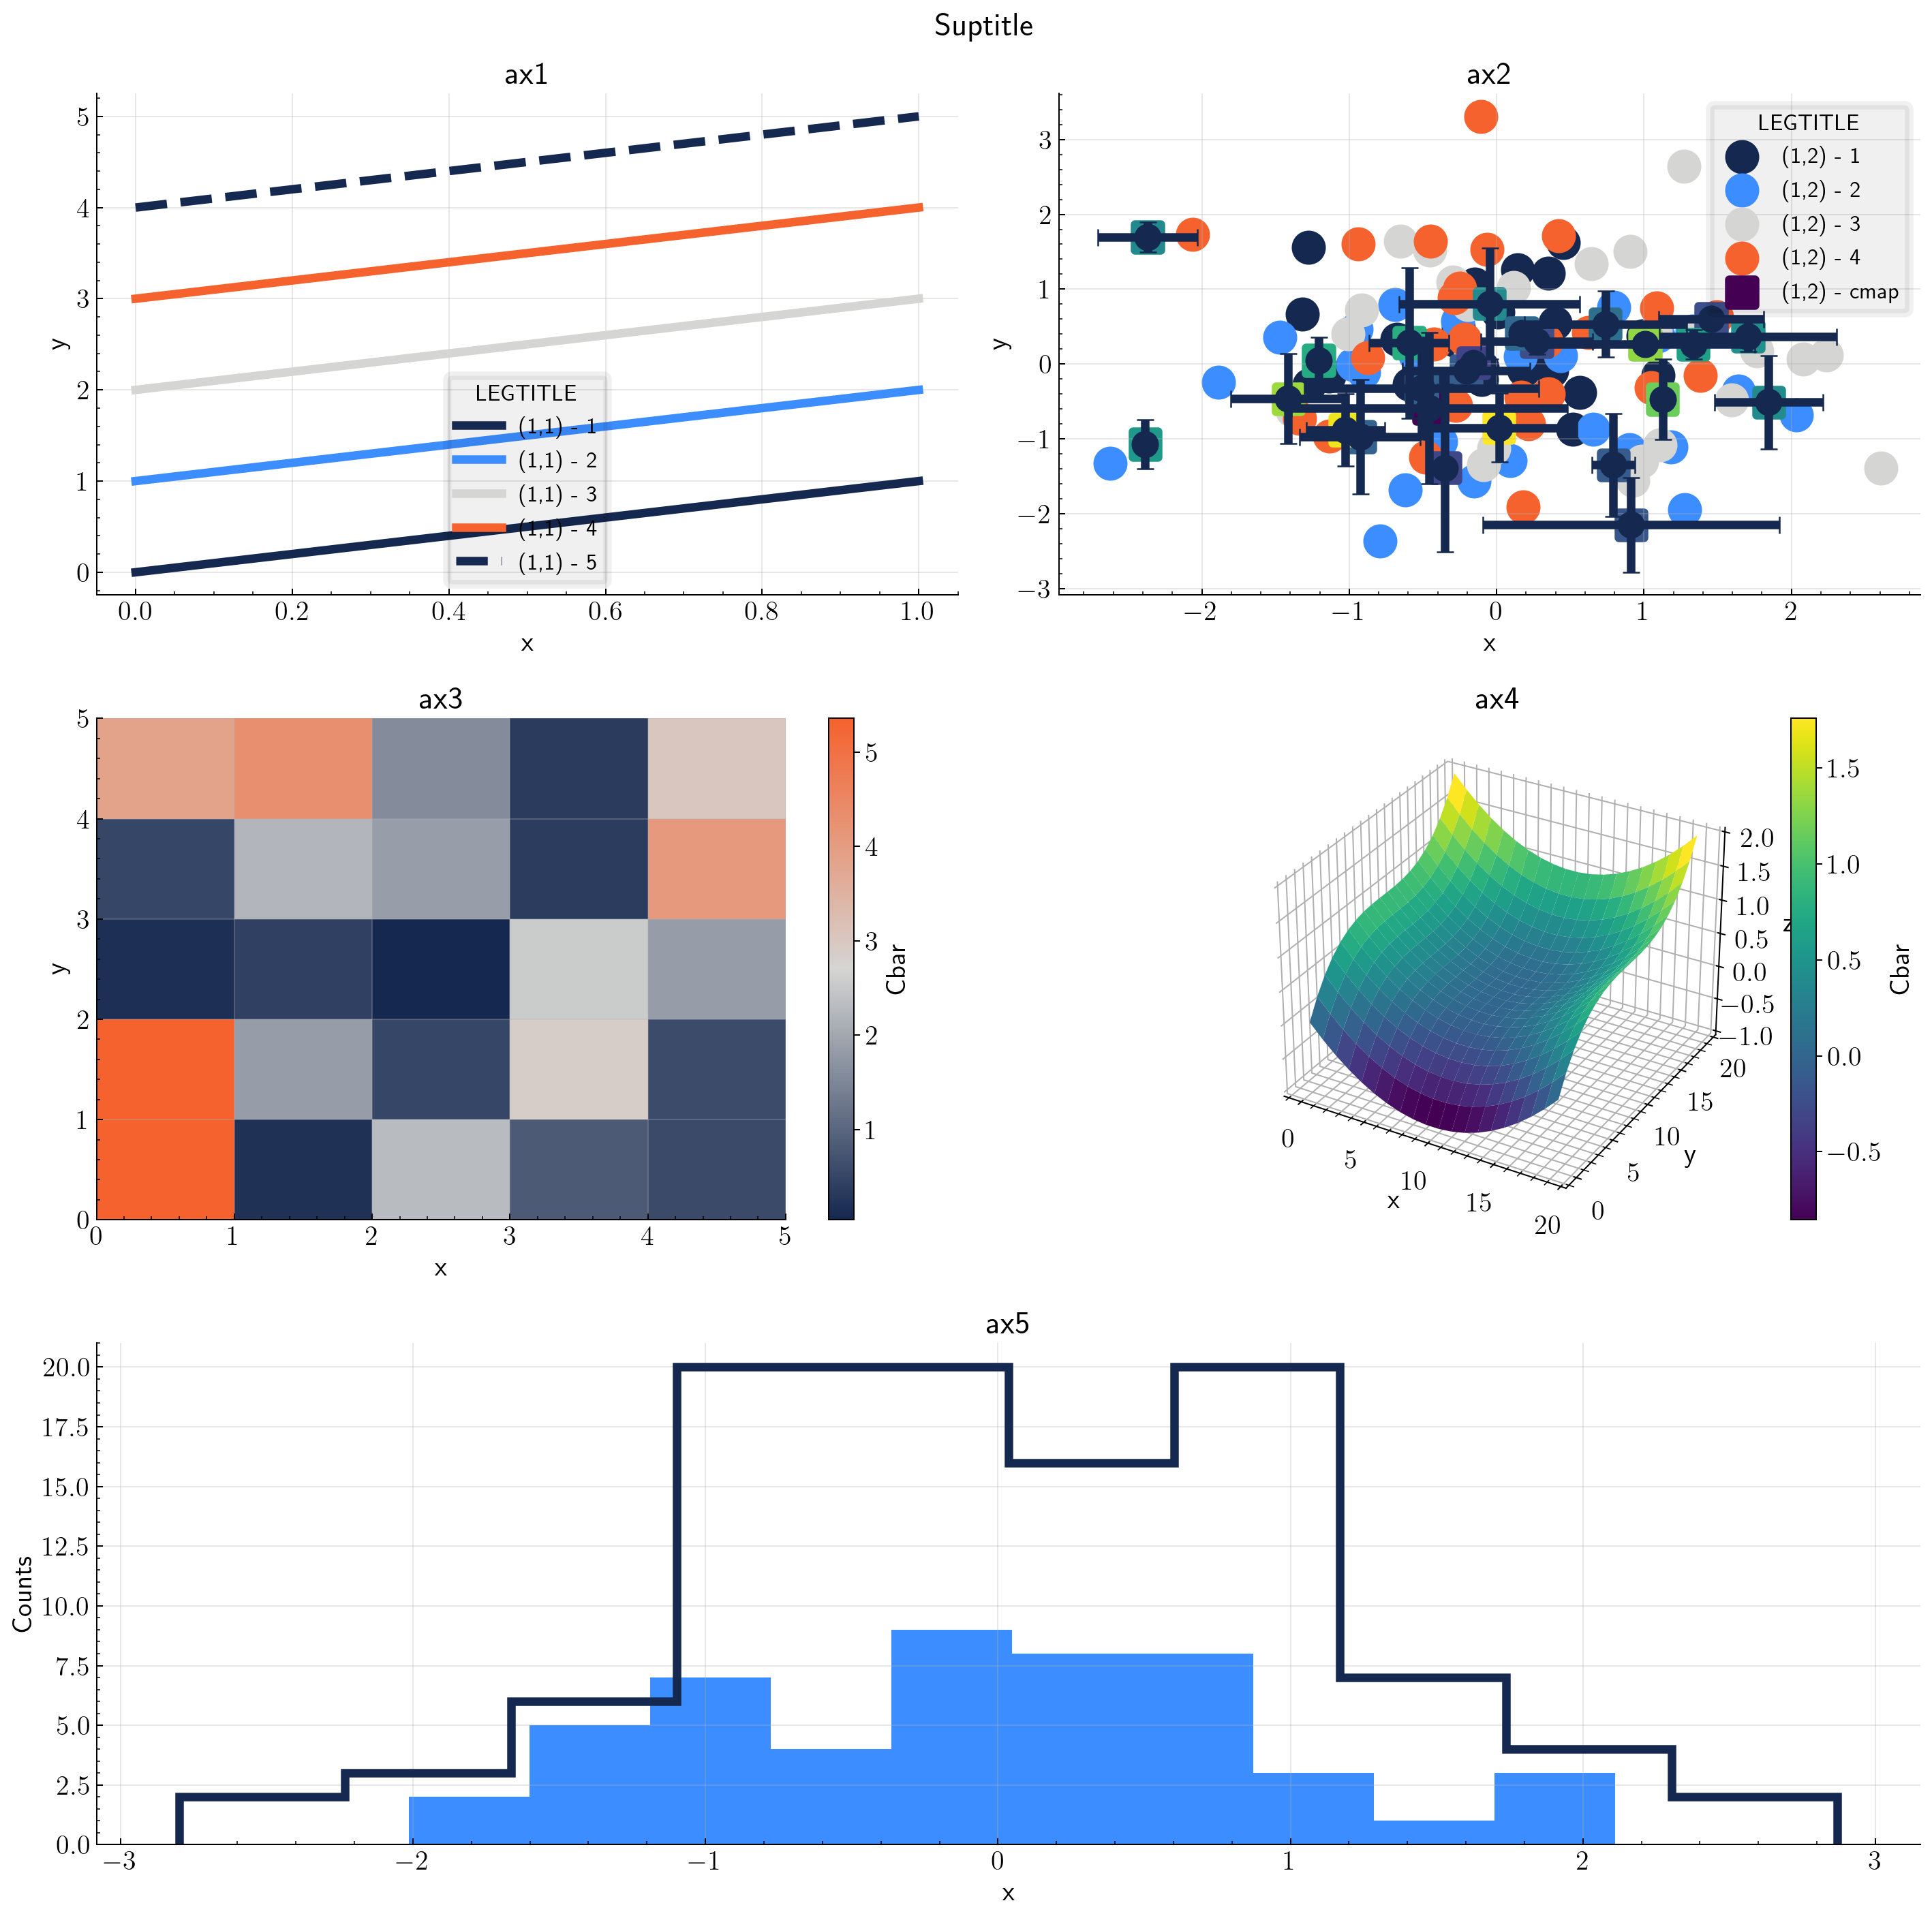

In [232]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.fink("light","batch")

style_testplot(colorway, ls, markers, cmap, hatches)

# Quick Customizations

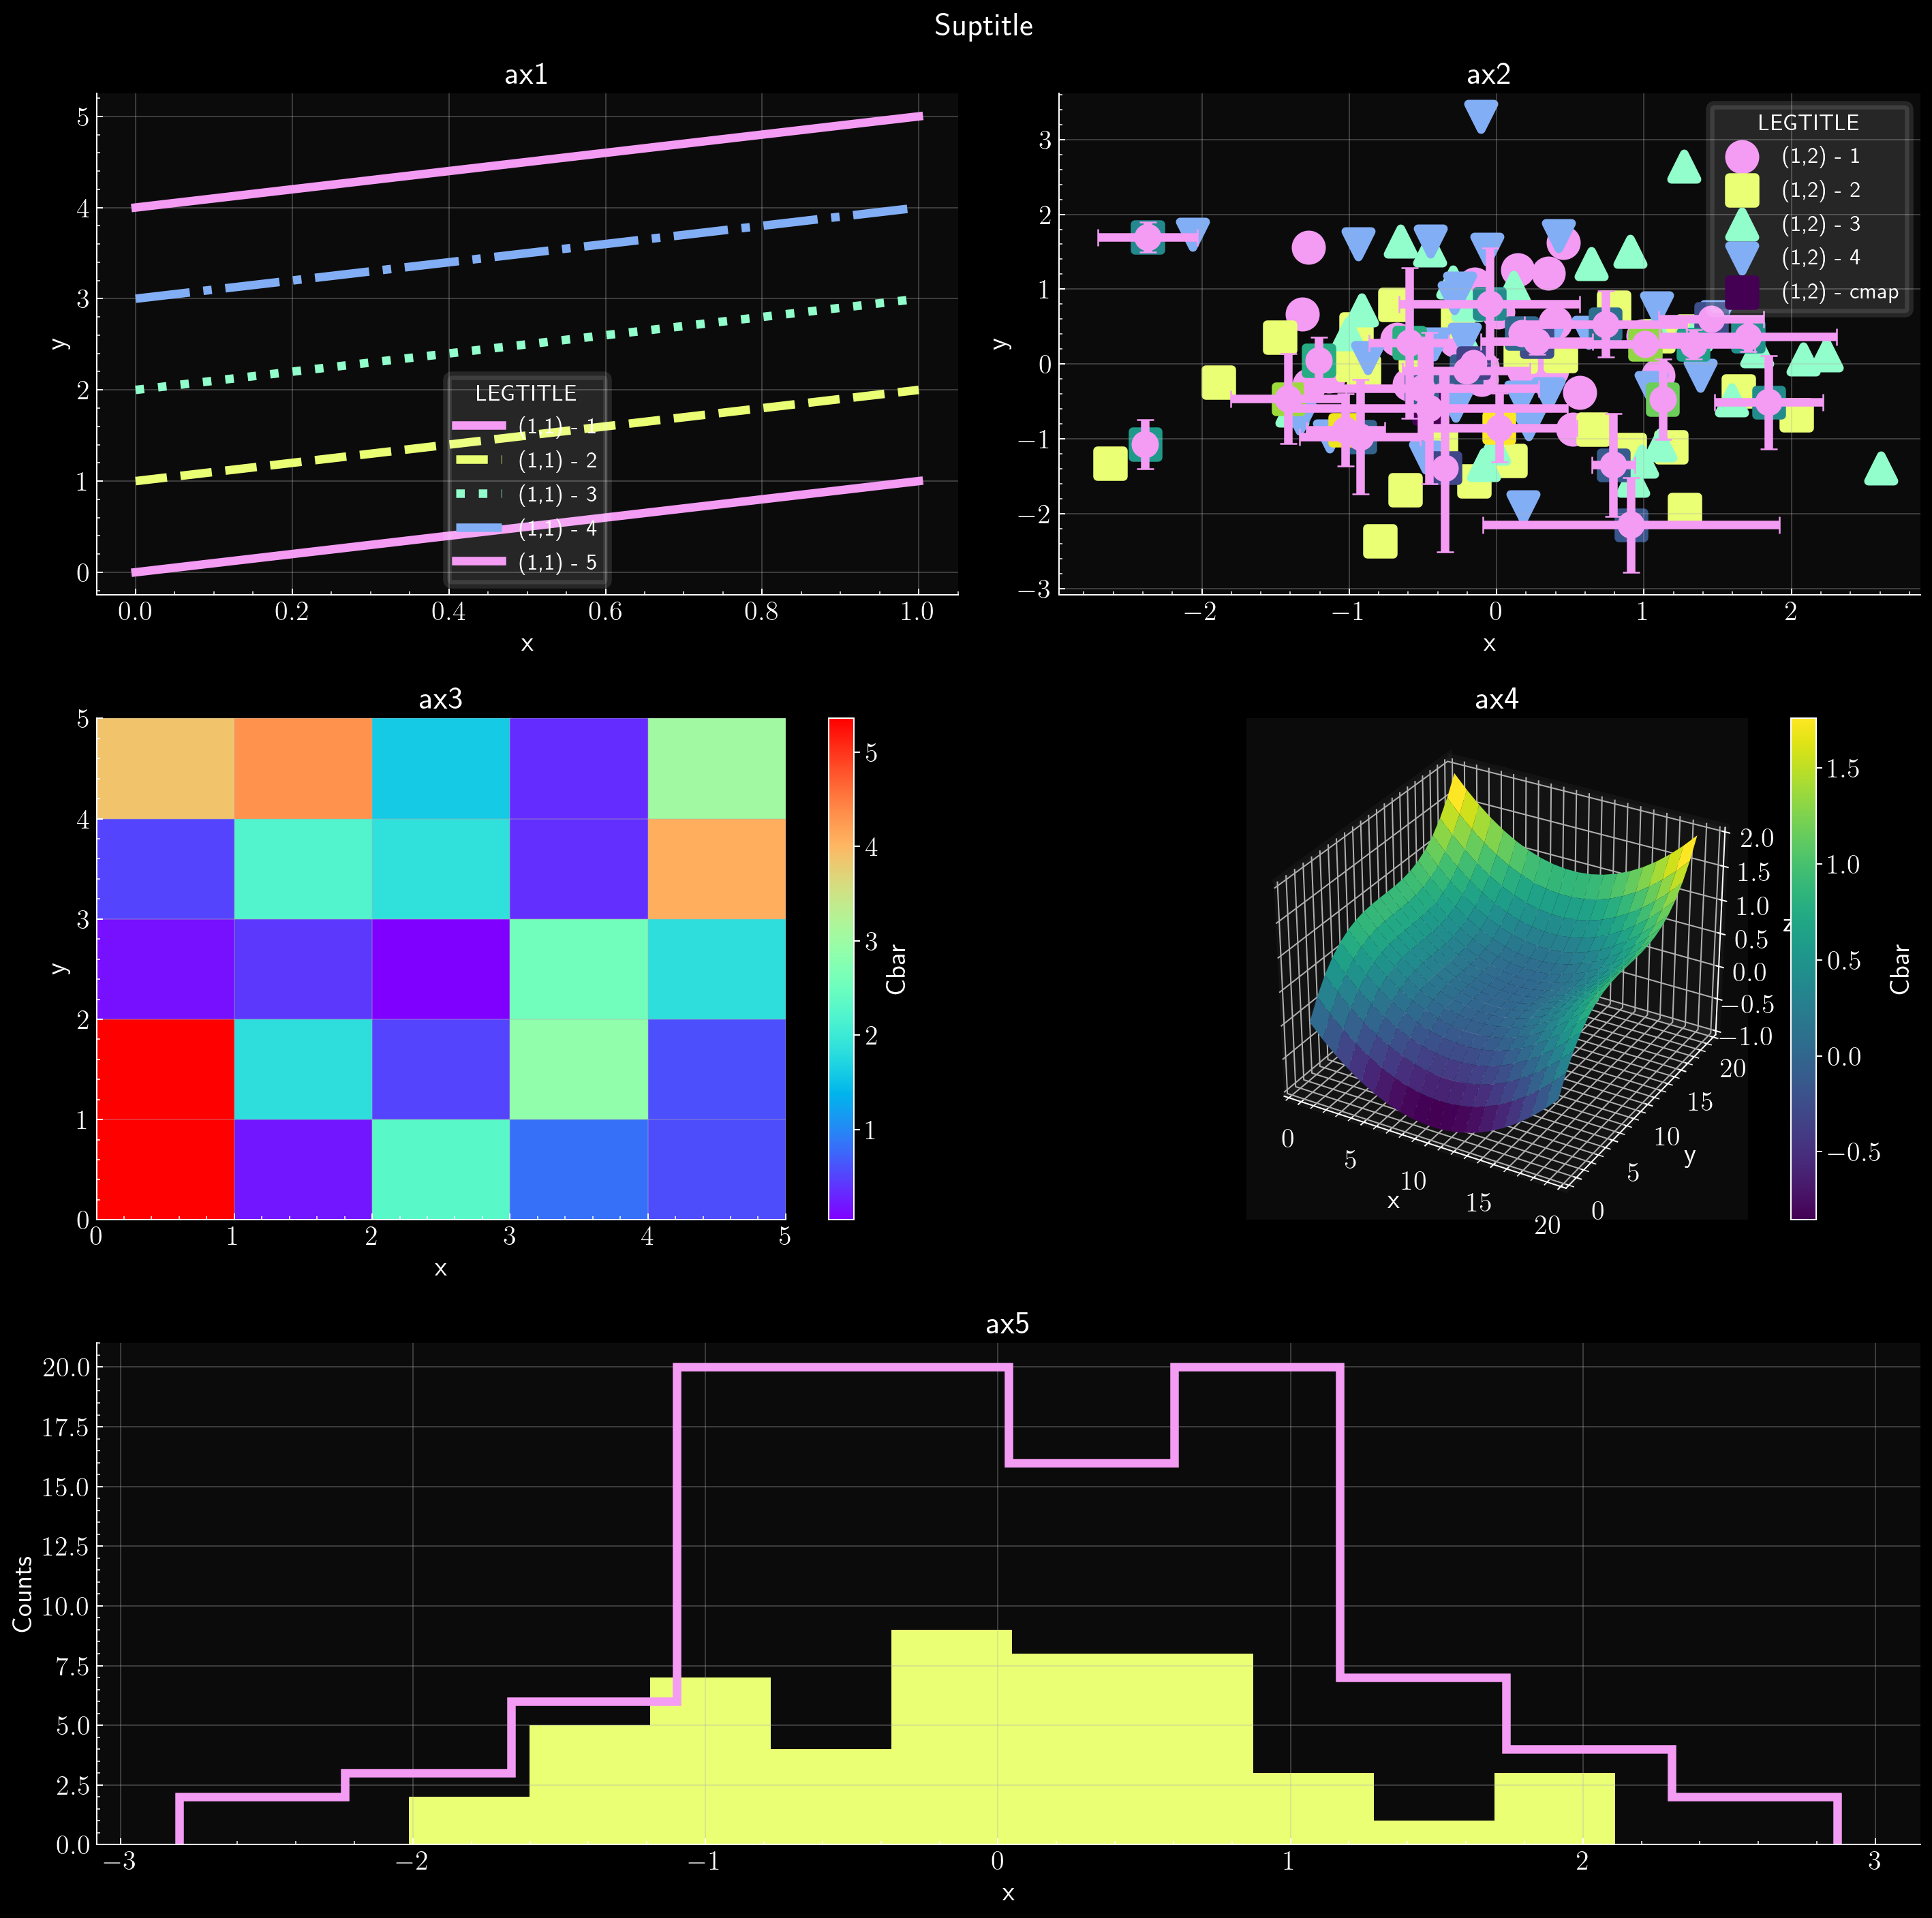

In [233]:
importlib.reload(alstms)

colorway, ls, markers, cmap, hatches = alstms.tre("dark","cycle", colorway_override=["#f49bf4","#eaff74","#91fecb","#82aef6"], cmap_override="rainbow")

style_testplot(colorway, ls, markers, cmap, hatches)